In [182]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr

# Read in CSV
df = pd.read_csv('../dataset/online_retail.csv')

# Clean Columns
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['CustomerID'] = df['CustomerID'].astype('Int64')

df['Cancelled'] = df['InvoiceNo'].str.startswith('C')
df['InvoiceNo'].mask(df['Cancelled'],df['InvoiceNo'].str[1:], inplace=True)

df = df[df.StockCode.str.len() <= 6]
df['StockCode'] = df['StockCode'].str[0:5]
df = df[df.StockCode.str.isnumeric()]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Remove Damage Instances
df_qsum = df[~df.Cancelled].groupby('StockCode', observed=True,)['Quantity'].sum()
problem_instances = df[(df.StockCode.isin(df_qsum[df_qsum < 0].index)) & (df.Quantity < 0) & (~df.Cancelled)].index
df.drop(index=problem_instances,inplace=True)

# Separating Data
df_full = df
df = df[~df.Cancelled].copy()

In [185]:
# Create Grouped Dataset
df = df_full[~df_full.Cancelled].copy()
customers_group = df.groupby('CustomerID', observed=True)['TotalPrice'].agg(TotalSpending='sum').sort_values(by='TotalSpending', ascending=False)

customers_group['SpendingBand'] = pd.cut(
    customers_group['TotalSpending'], 
    bins=[0,1000,10000,float('inf')], 
    labels=['Low', 'Medium', 'High']
)

df = df.merge(customers_group, on='CustomerID', how='left')

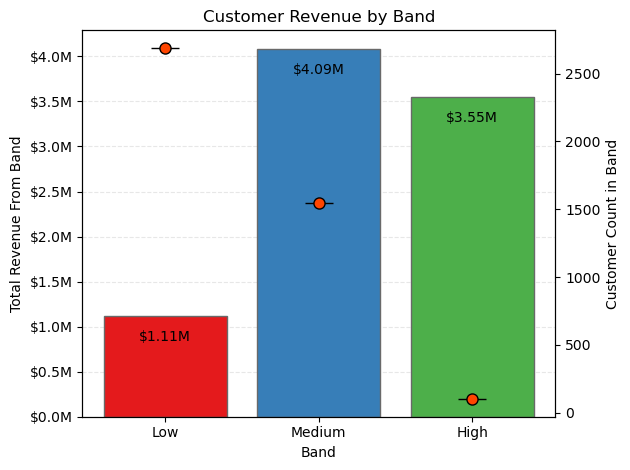

In [161]:
# Setup
spending_band_counts = customers_group['SpendingBand'].value_counts()
spending_band_sums = customers_group.groupby('SpendingBand', observed=True)['TotalSpending'].sum()

fig, ax1 = plt.subplots()

# Bar
colors = plt.cm.Set1(range(3))
bar1 = ax1.bar(x=spending_band_sums.index, height=spending_band_sums, color=colors, edgecolor='dimgray')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y/1000000:.1f}M'))
ax1.grid(axis='y', ls='--', alpha=0.3)
ax1.set_axisbelow(True)
ax1.bar_label(bar1, [f'${x/1000000:.2f}M' for x in spending_band_sums], padding=-20)
ax1.set_ylabel('Total Revenue From Band')
ax1.set_xlabel('Band')
ax1.set_title('Customer Revenue by Band')


# Points
ax2 = ax1.twinx()
ax2.plot(spending_band_counts, marker='_', color='orangered', linestyle='None', markeredgecolor='black', ms=20)
ax2.plot(spending_band_counts, marker='o', color='orangered', linestyle='None', markeredgecolor='black', ms=8)
labels1 =  [f'${x/1000000:.2f}M' for x in spending_band_sums]
ax2.set_ylabel('Customer Count in Band')

# Finish
plt.tight_layout()


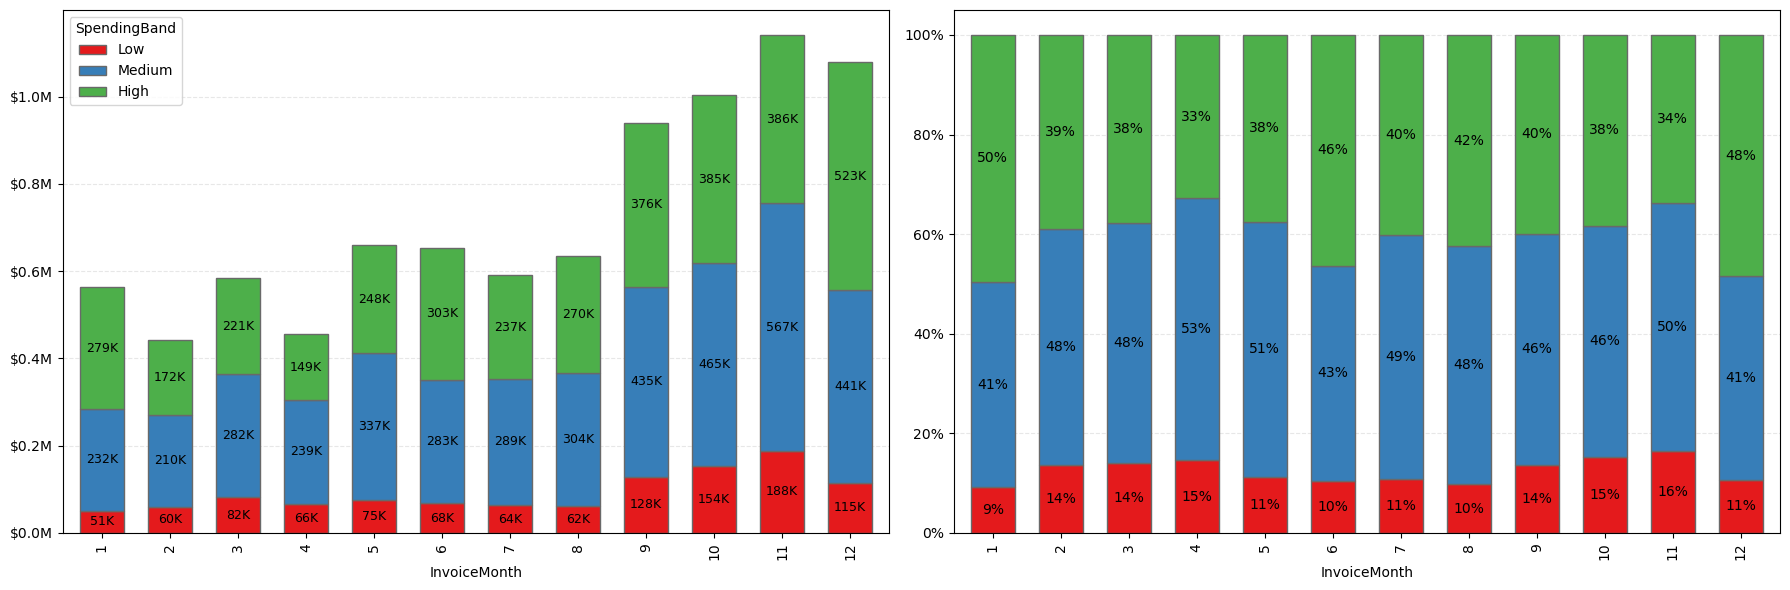

In [261]:
# Setup
month_revenue = df.groupby(['InvoiceMonth','SpendingBand'], observed=True)['TotalPrice'].sum().unstack()
month_revenue_percent = month_revenue.div(month_revenue.sum(axis=1), axis=0)

fig, ax = plt.subplots(1,2)
fig.set_size_inches(18,6)

# Revenue Bars
month_revenue.plot(ax=ax[0], kind='bar', stacked=True, color=colors, edgecolor='dimgray', width=0.65)
ax[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000000:.1f}M'))
ax[0].grid(axis='y', linestyle='--', alpha=0.3)
ax[0].set_axisbelow(True)

for container in ax[0].containers:
    ax[0].bar_label(
        container,
        fmt=lambda x: f'{x/1000:.0f}K',
        label_type='center',
        fontsize=9,
        color='black'
    )
    
# Percentage Bars
month_revenue_percent.plot(ax=ax[1], kind='bar', stacked=True, color=colors, edgecolor='dimgray', legend=False, width=0.65)
ax[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax[1].grid(axis='y', linestyle='--', alpha=0.3)
ax[1].set_axisbelow(True)

for container in ax[1].containers:
    ax[1].bar_label(
        container,
        fmt=lambda x: f'{x*100:.0f}%',
        label_type='center',
        fontsize=10,
        color='black'
    )


# Finish
plt.tight_layout()

In [219]:
[print(y) for y in month_revenue_total['TotalRevenue']]

670829.68
508085.82
690369.31
515584.65
739963.99
737802.48
686564.38
724141.15
1028873.33
1103711.66
1456671.43
1391521.01


[None, None, None, None, None, None, None, None, None, None, None, None]